# Basic Usage

In [1]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

from py21cmemu import Emulator

rcParams.update({"font.size": 40})

/home/dbreitman/.conda/envs/pytorch_env/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


We begin by loading the data sample. This is a small subsample of 100 test set elements. 

In [2]:
test_sample = np.load("Test_data_sample.npz")
print(list(test_sample.keys()))

['X_test', 'parameters', 'limits', 'Ts', 'Tb', 'PS', 'tau', 'UVLFs', 'xHI']


Now we load the astro params. The test set stores parameters in normalized [0,1] space, so we convert them back to physical units using `DefaultEmulatorInput.undo_normalization()`. Parameters in `LOG_PARAMETERS` (F_STAR10, F_ESC10, M_TURN, L_X) are returned in log10 space.

In [ ]:
from py21cmemu.inputs import DefaultEmulatorInput

# X_test is stored in [0,1] normalized space; convert to physical units first.
# Log-space parameters (F_STAR10, F_ESC10, M_TURN, L_X) are returned in log10.
# NU_X_THRESH is returned in eV.
test_params = DefaultEmulatorInput().undo_normalization(test_sample["X_test"])
print(f"Parameter shape: {test_params.shape}")
print(f"Example params (log10 for log params, eV for NU_X_THRESH):\n{test_params[0]}")

Here we load the `21cmFAST` summaries for these parameters.

In [4]:
Tb_true = test_sample["Tb"]
xHI_true = test_sample["xHI"]

## Get emulated summaries with 21cmEMU

In [5]:
emu = Emulator(emulator="acg")
normed_input_params, output, output_errors = emu.predict(test_params, verbose=True)

In [6]:
Tb_emu = output["Tb"].value
xHI_emu = output["xHI"].value
zs = output["redshifts"].value

We plot the emulated summary (dash-dotted) vs the true summary from the test set (solid line). We define a generic function to do all of the plotting.

In [7]:
def plot_true_vs_emu(
    x,
    y_true,
    y_emu,
    x_label,
    y_label,
    xlims=None,
    N=10,
    offset=0,
    cs=None,
    leg_loc=(0.5, 0.5),
):
    if cs is None:
        cs = [
            "k",
            "lime",
            "b",
            "orange",
            "cyan",
            "magenta",
            "grey",
            "pink",
            "darkred",
            "coral",
        ]
    y_diff = abs(y_true - y_emu)
    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        figsize=(14, 12),
        gridspec_kw=dict(height_ratios=[3, 2], hspace=0),
    )
    axs = axs.flatten()

    diff_err_z = np.nanpercentile(y_diff, [2.5, 16, 50, 84, 97.5], axis=0)
    for i, c in zip(range(N), cs, strict=False):
        if i == N - 1:
            labels = ["21cmEMU", "Test Set"]
        else:
            labels = [None, None]
        axs[0].plot(x, y_true[i + offset, :], lw=3, color=c, label=labels[1])
        axs[1].plot(x, y_diff[i + offset, :], ls="-.", alpha=0.5, lw=2, color=c)
        axs[0].plot(x, y_emu[i + offset, :], lw=2, ls="-.", color=c, label=labels[0])

    axs[0].legend(loc=leg_loc, frameon=False)  # framealpha=0.3)
    axs[1].plot(x, diff_err_z[2, :], ls="--", lw=3, color="k", label=r"Median")
    axs[1].fill_between(
        x, diff_err_z[1, :], diff_err_z[3, :], color="k", alpha=0.2, label=r"68% CI"
    )
    axs[1].fill_between(
        x, diff_err_z[0, :], diff_err_z[4, :], color="k", alpha=0.1, label=r"95% CI"
    )

    handles = [
        mpatches.Patch(color="k", label="68% CI", alpha=0.3),
        mpatches.Patch(color="k", label="95% CI", alpha=0.1),
    ]
    plt.legend(handles=handles, loc=(0.6, 0.5), frameon=False)
    axs[0].set_ylabel(y_label)
    axs[1].set_ylabel(r"Abs Diff")
    axs[1].set_xlabel(x_label)
    if xlims is not None:
        plt.xlim(xlims[0], xlims[1])
    else:
        plt.xlim(min(x), max(x))
    plt.tight_layout()
    plt.show()

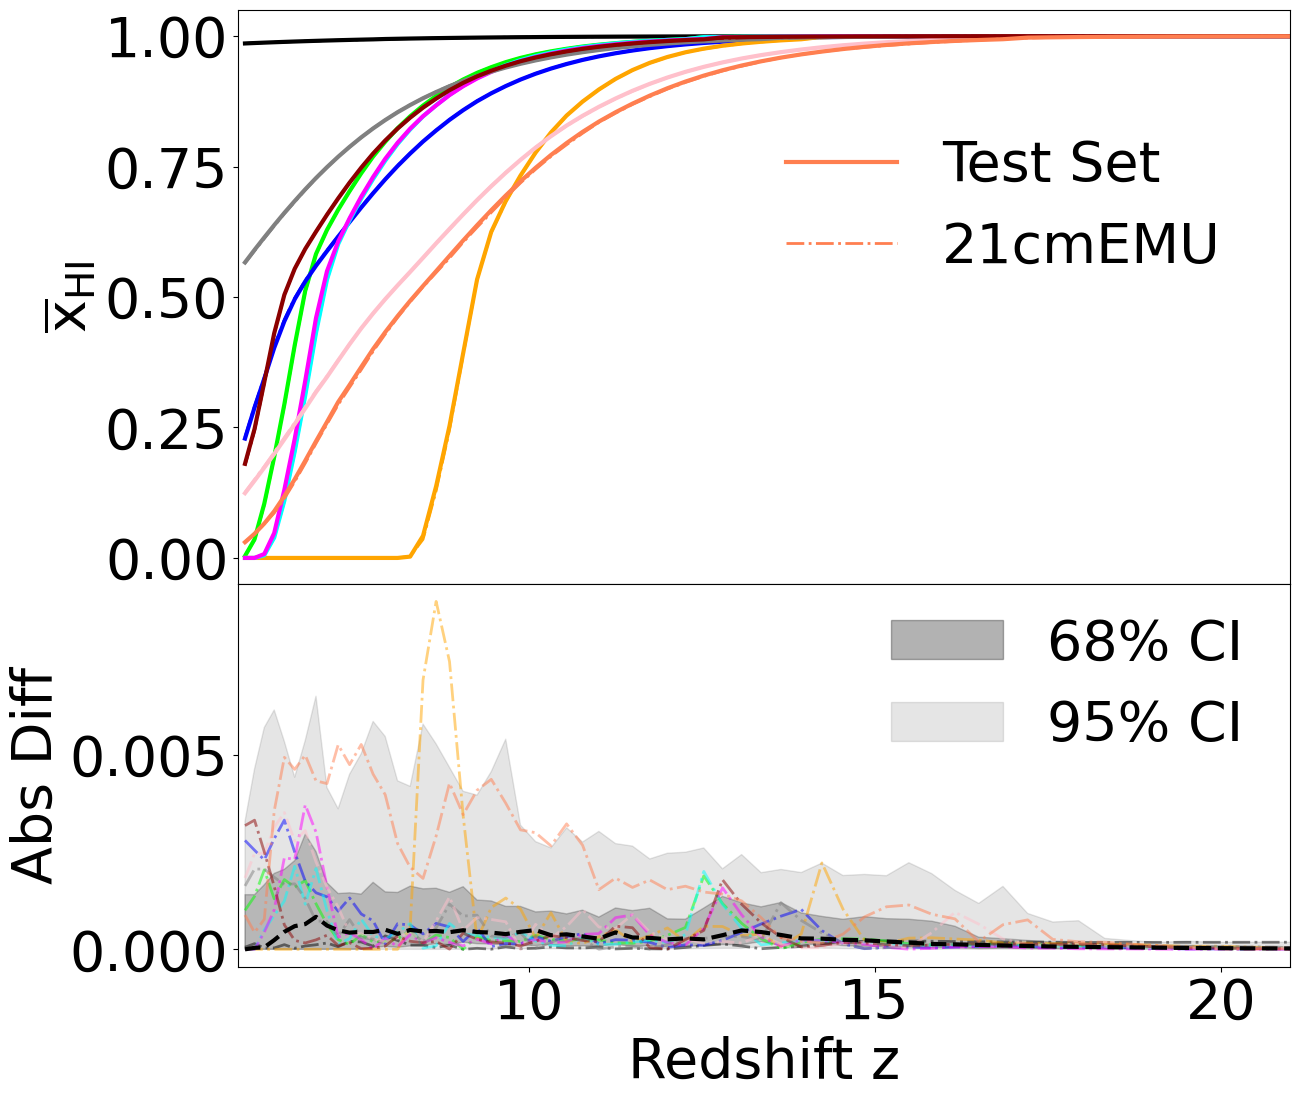

In [8]:
plot_true_vs_emu(
    zs,
    xHI_true,
    xHI_emu,
    r"Redshift z",
    r"$\overline{\mathrm{x}}_{\rm{HI}}$",
    xlims=[5.8, 21],
)

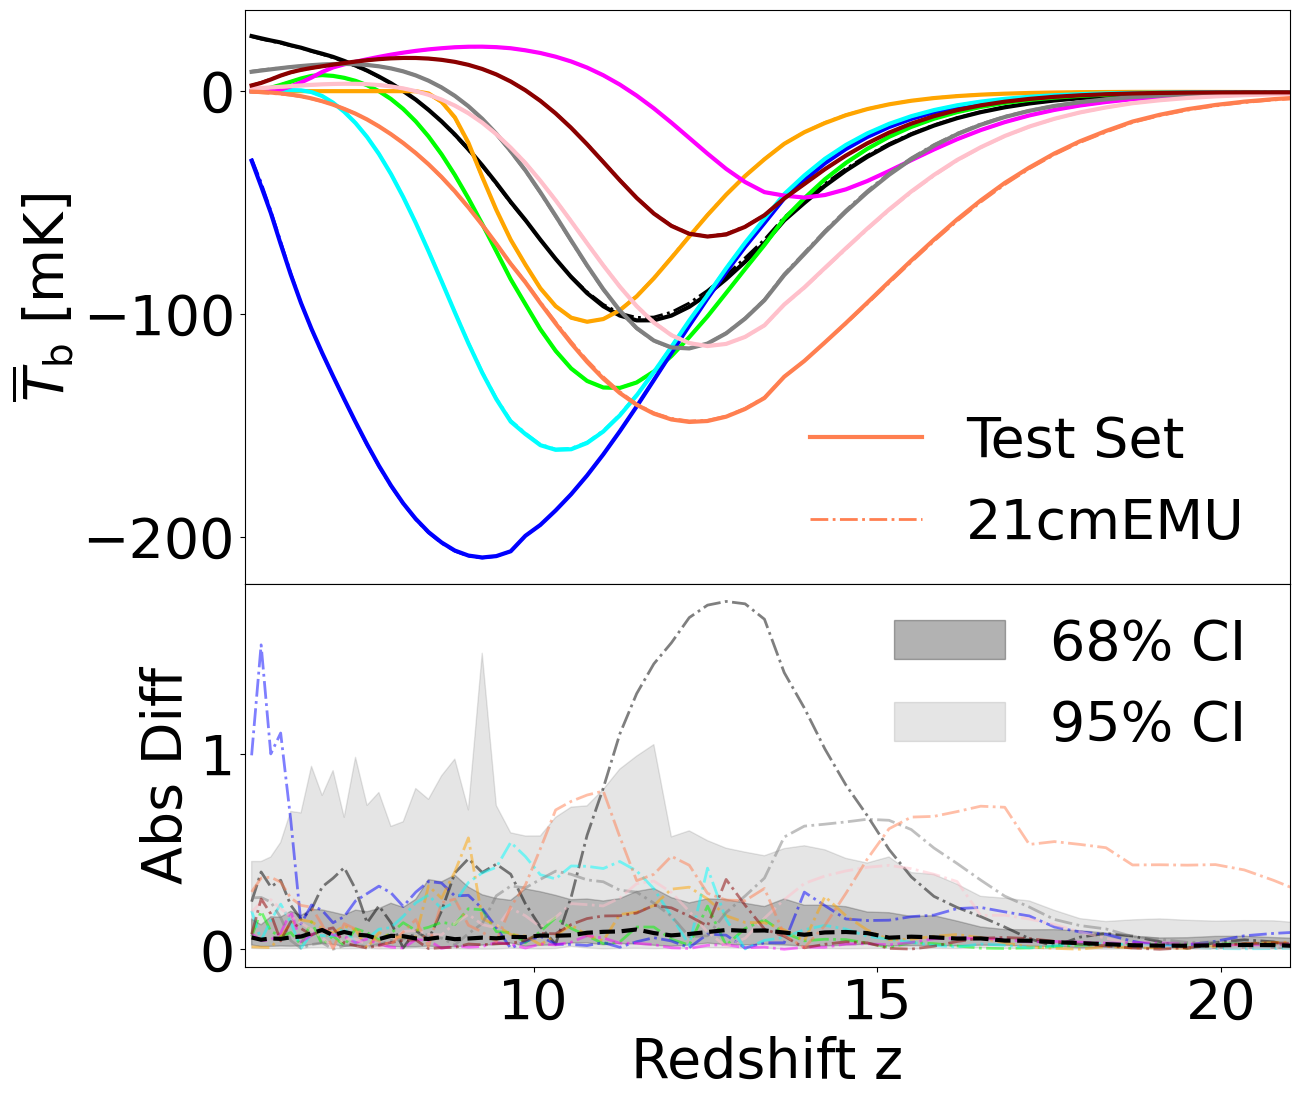

In [9]:
plot_true_vs_emu(
    zs,
    Tb_true,
    Tb_emu,
    r"Redshift z",
    r"$\overline{T}_{\rm{b}}$ [mK]",
    xlims=[5.8, 21],
    leg_loc=(0.52, 0.02),
)

These plots are the same as the ones in [Breitman et al., 2023](https://arxiv.org/abs/2309.05697) (except for the 68% and 95% credible intervals, which are calculated on a small subsample of the test set here). 
You can try making more of these same plots for other summaries e.g. power spectrum, spin temperature, etc.

## Understanding Emulator Errors

The `predict()` method returns error statistics as the third element. For the ACG (default) emulator, these are provided as `ACGEmulatorErrors`, containing **fractional errors (FE%)** from the test set.

These errors tell you the typical percentage accuracy of the emulator at each (redshift, k-mode) or (redshift, magnitude) bin.

In [10]:
# Inspect the error object
print(f"Error type: {type(output_errors).__name__}")
print(f"\nAvailable error fields: {output_errors.keys()}")
print(f"\nError summary:\n{output_errors.summary()}")

Error type: ACGEmulatorErrors

Available error fields: ['PS_err', 'Tb_err', 'xHI_err', 'Ts_err', 'tau_err', 'UVLFs_err', 'UVLFs_logerr']

Error summary:
Emulator Error Statistics
PS_err: median=0.14 (PS fractional error (FE%))
Tb_err: median=0.05 (Tb fractional error (FE%))
xHI_err: median=0.00 (xHI fractional error (FE%))
Ts_err: median=0.04 (Ts fractional error (FE%))
tau_err: median=0.00 (tau fractional error (FE%))
UVLFs_err: median=0.00 (Linear UVLF fractional error (FE%))
UVLFs_logerr: median=0.01 (Log UVLF fractional error (FE%))


### Accessing Individual Error Fields

Each error field has astropy units attached (as percent). You can access them via attributes or dict-like syntax:

In [11]:
# Attribute access
print(f"PS error shape: {output_errors.PS_err.shape}")
print(f"PS error unit: {output_errors.PS_err.unit}")
print(f"Median PS FE%: {np.median(output_errors.PS_err.value):.2f}%")

# Dict-like access
print(f"\nTb error shape: {output_errors['Tb_err'].shape}")
print(f"Median Tb FE%: {np.median(output_errors['Tb_err'].value):.2f}%")

# Check if field exists
print(f"\n'xHI_err' in errors: {'xHI_err' in output_errors}")

PS error shape: (60, 12)
PS error unit: %
Median PS FE%: 0.14%

Tb error shape: (84,)
Median Tb FE%: 0.05%

'xHI_err' in errors: True


### Visualizing Error Statistics

Let's plot the fractional error as a function of redshift for 1D summaries:

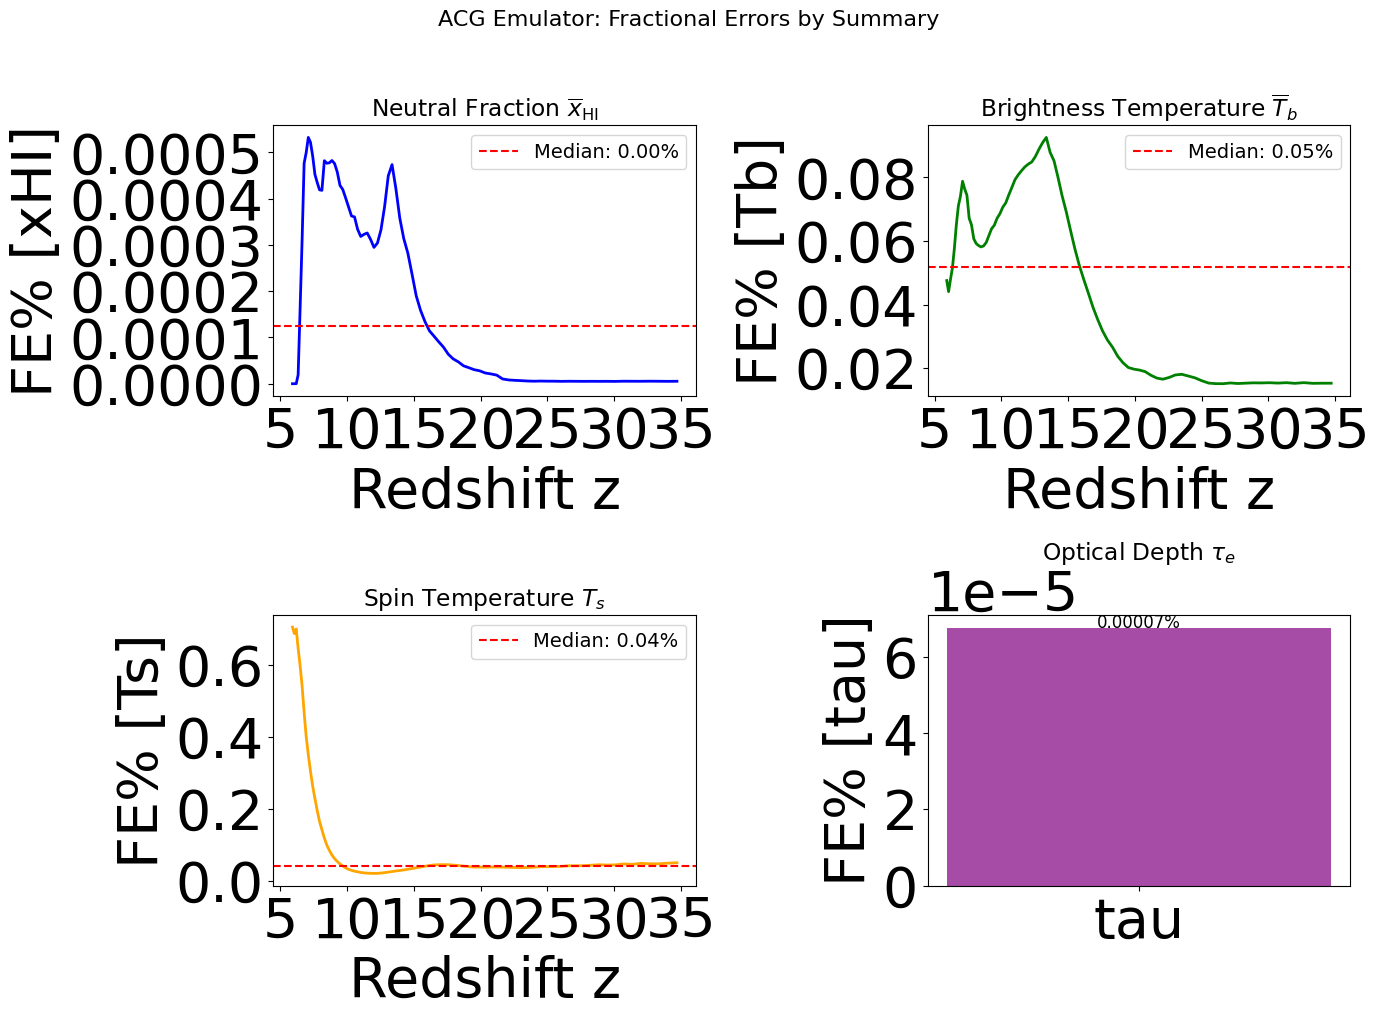

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
rcParams.update({"font.size": 14})

# xHI error vs redshift
axes[0, 0].plot(zs, output_errors.xHI_err.value, "b-", lw=2)
axes[0, 0].set_xlabel("Redshift z")
axes[0, 0].set_ylabel("FE% [xHI]")
axes[0, 0].set_title(r"Neutral Fraction $\overline{x}_{\rm HI}$")
axes[0, 0].axhline(
    np.median(output_errors.xHI_err.value),
    color="r",
    ls="--",
    label=f"Median: {np.median(output_errors.xHI_err.value):.2f}%",
)
axes[0, 0].legend()

# Tb error vs redshift
axes[0, 1].plot(zs, output_errors.Tb_err.value, "g-", lw=2)
axes[0, 1].set_xlabel("Redshift z")
axes[0, 1].set_ylabel("FE% [Tb]")
axes[0, 1].set_title(r"Brightness Temperature $\overline{T}_b$")
axes[0, 1].axhline(
    np.median(output_errors.Tb_err.value),
    color="r",
    ls="--",
    label=f"Median: {np.median(output_errors.Tb_err.value):.2f}%",
)
axes[0, 1].legend()

# Ts error vs redshift
axes[1, 0].plot(zs, output_errors.Ts_err.value, "orange", lw=2)
axes[1, 0].set_xlabel("Redshift z")
axes[1, 0].set_ylabel("FE% [Ts]")
axes[1, 0].set_title(r"Spin Temperature $T_s$")
axes[1, 0].axhline(
    np.median(output_errors.Ts_err.value),
    color="r",
    ls="--",
    label=f"Median: {np.median(output_errors.Ts_err.value):.2f}%",
)
axes[1, 0].legend()

# tau error (scalar)
axes[1, 1].bar(["tau"], [output_errors.tau_err.value], color="purple", alpha=0.7)
axes[1, 1].set_ylabel("FE% [tau]")
axes[1, 1].set_title(r"Optical Depth $\tau_e$")
axes[1, 1].text(
    0,
    output_errors.tau_err.value,
    f"{output_errors.tau_err.value:.5f}%",
    ha="center",
    fontsize=12,
)

plt.suptitle("ACG Emulator: Fractional Errors by Summary", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Computing Absolute Errors

The ACG emulator stores fractional errors (FE%). To get absolute errors in physical units, multiply by the output value:

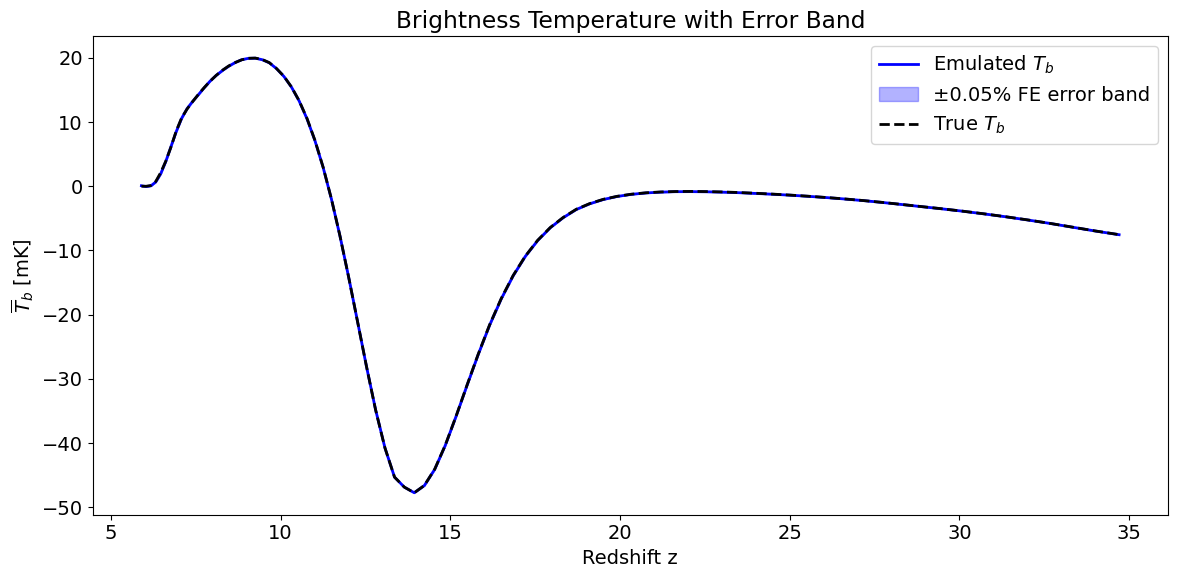

In [13]:
# Convert FE% to absolute errors for plotting with error bands
abs_Tb_err = output_errors.Tb_err.value / 100 * np.abs(Tb_emu)  # Now in mK
abs_xHI_err = output_errors.xHI_err.value / 100 * np.abs(xHI_emu)

# Example plot with error bands
fig, ax = plt.subplots(figsize=(12, 6))

# Plot one sample with error band
sample_idx = 5
ax.plot(zs, Tb_emu[sample_idx], "b-", lw=2, label="Emulated $T_b$")
ax.fill_between(
    zs,
    Tb_emu[sample_idx] - abs_Tb_err[sample_idx],
    Tb_emu[sample_idx] + abs_Tb_err[sample_idx],
    alpha=0.3,
    color="blue",
    label="±0.05% FE error band",
)
ax.plot(zs, Tb_true[sample_idx], "k--", lw=2, label="True $T_b$")

ax.set_xlabel("Redshift z")
ax.set_ylabel(r"$\overline{T}_b$ [mK]")
ax.legend()
ax.set_title("Brightness Temperature with Error Band")
plt.tight_layout()
plt.show()